# Image Captioning with Xception + LSTM (Flickr8k)

Pipeline: Mount Drive → Extract Features → Prepare Captions → Tokenize → Train → Generate Captions

## Step 1: Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2: Imports & Paths

In [5]:
import os
import string
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pickle import dump, load
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.applications.xception import Xception, preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add
from tensorflow.keras.models import Model, load_model

# ── Paths ──────────────────────────────────────────────────────────────────
BASE        = "/content/drive/MyDrive/ImageCaptioning"
IMAGES_DIR  = BASE + "/Flickr8k_Dataset"
CAPTIONS_TXT= BASE + "/Flickr8k_text.txt"
DESC_FILE   = BASE + "/descriptions.txt"
FEATURES_PKL= BASE + "/features.pkl"
TOKENIZER_PKL=BASE + "/tokenizer.pkl"
XCEPTION_W  = BASE + "/xception.weights.h5"
MODEL_DIR   = BASE + "/models"
os.makedirs(MODEL_DIR, exist_ok=True)

print("✅ Imports and paths ready.")

✅ Imports and paths ready.


## Step 3: Load & Clean Captions

In [6]:
def load_captions(filename):
    """Parse Flickr8k captions file → {img_id: [caption, ...]}"""
    with open(filename, 'r', encoding='utf-8') as f:
        text = f.read()

    descriptions = {}
    for line in text.split('\n'):
        line = line.strip()
        if not line:
            continue
        # Support both tab-separated and space-separated formats
        if '\t' in line:
            img, caption = line.split('\t', 1)
        else:
            parts = line.split()
            img, caption = parts[0], ' '.join(parts[1:])
        img = img.split('#')[0]  # remove #0, #1 etc.
        descriptions.setdefault(img, []).append(caption)
    return descriptions


def clean_captions(descriptions):
    """Lowercase, remove punctuation, remove short/non-alpha words."""
    table = str.maketrans('', '', string.punctuation)
    for img, caps in descriptions.items():
        for i, cap in enumerate(caps):
            words = cap.replace('-', ' ').split()
            words = [w.lower().translate(table) for w in words]
            words = [w for w in words if len(w) > 1 and w.isalpha()]
            descriptions[img][i] = ' '.join(words)
    return descriptions


def save_descriptions(descriptions, filename):
    lines = [f"{img}\t{cap}" for img, caps in descriptions.items() for cap in caps]
    with open(filename, 'w', encoding='utf-8') as f:
        f.write('\n'.join(lines))


descriptions = load_captions(CAPTIONS_TXT)
descriptions = clean_captions(descriptions)
save_descriptions(descriptions, DESC_FILE)

vocab = set(w for caps in descriptions.values() for cap in caps for w in cap.split())
print(f"Images: {len(descriptions)} | Vocabulary: {len(vocab)}")
print("✅ Captions saved to:", DESC_FILE)

Images: 21672 | Vocabulary: 8341
✅ Captions saved to: /content/drive/MyDrive/ImageCaptioning/descriptions.txt


## Step 4: Extract Image Features (Xception)

In [7]:
# Load or cache Xception (saves re-downloading on Colab restarts)
if os.path.exists(XCEPTION_W):
    print("Loading cached Xception weights...")
    xception_model = Xception(include_top=False, pooling='avg', weights=None)
    xception_model.load_weights(XCEPTION_W)
else:
    print("Downloading Xception weights (first time)...")
    xception_model = Xception(include_top=False, pooling='avg', weights='imagenet')
    xception_model.save_weights(XCEPTION_W)
    print("Weights cached to Drive.")


def extract_features(directory):
    """Extract 2048-d Xception features for every image in directory."""
    features = {}
    for pic in tqdm(os.listdir(directory)):
        path = os.path.join(directory, pic)
        try:
            img = Image.open(path).convert('RGB').resize((299, 299))
            img = preprocess_input(np.expand_dims(img_to_array(img), axis=0))
            features[pic.split('.')[0]] = xception_model.predict(img, verbose=0)[0]
        except Exception as e:
            print(f"Skipping {pic}: {e}")
    return features


def extract_single_feature(img_path):
    """Extract feature for one image (used at inference)."""
    img = Image.open(img_path).convert('RGB').resize((299, 299))
    img = preprocess_input(np.expand_dims(img_to_array(img), axis=0))
    return xception_model.predict(img, verbose=0)[0]


if os.path.exists(FEATURES_PKL):
    print("Loading cached features...")
    with open(FEATURES_PKL, 'rb') as f:
        features = load(f)
else:
    print("Extracting features (this takes a while)...")
    features = extract_features(IMAGES_DIR)
    with open(FEATURES_PKL, 'wb') as f:
        dump(features, f)
    print("Features saved.")

print(f"✅ Features loaded: {len(features)} images")

Loading cached Xception weights...
Loading cached features...
✅ Features loaded: 8092 images


## Step 5: Load Descriptions & Build Tokenizer

In [8]:
def load_descriptions_file(filename):
    """Load cleaned descriptions file → {img_id: ['startseq ... endseq', ...]}"""
    descriptions = {}
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split('\t', 1)
            if len(parts) < 2:
                continue
            img, cap = parts
            img = img.split('.')[0]
            desc = 'startseq ' + cap + ' endseq'
            descriptions.setdefault(img, []).append(desc)
    return descriptions


# Load descriptions
train_descriptions = load_descriptions_file(DESC_FILE)

# Match features (normalize keys)
features_norm = {k.split('.')[0]: v for k, v in features.items()}
train_features = {k: features_norm[k] for k in train_descriptions if k in features_norm}

print(f"Descriptions: {len(train_descriptions)} | Matched features: {len(train_features)}")

# Build tokenizer
all_captions = [cap for caps in train_descriptions.values() for cap in caps]
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
with open(TOKENIZER_PKL, 'wb') as f:
    dump(tokenizer, f)

vocab_size = len(tokenizer.word_index) + 1
max_len    = max(len(cap.split()) for cap in all_captions)

print(f"Vocab size: {vocab_size} | Max caption length: {max_len}")
print("✅ Tokenizer saved.")

Descriptions: 8091 | Matched features: 8091
Vocab size: 8344 | Max caption length: 34
✅ Tokenizer saved.


## Step 6: Data Generator & Model Definition

In [9]:
def create_sequences(tokenizer, max_len, desc_list, feature, vocab_size):
    X1, X2, y = [], [], []
    for desc in desc_list:
        seq = tokenizer.texts_to_sequences([desc])[0]
        for i in range(1, len(seq)):
            in_seq  = pad_sequences([seq[:i]], maxlen=max_len)[0]
            out_seq = to_categorical([seq[i]], num_classes=vocab_size)[0]
            X1.append(feature)
            X2.append(in_seq)
            y.append(out_seq)
    return np.array(X1), np.array(X2), np.array(y)


def data_generator(descriptions, features, tokenizer, max_len, vocab_size):
    while True:
        for key, desc_list in descriptions.items():
            if key not in features:
                continue
            X1, X2, y = create_sequences(tokenizer, max_len, desc_list, features[key], vocab_size)
            yield (X1, X2), y


def define_model(vocab_size, max_len):
    # Image branch
    inputs1 = Input(shape=(2048,))
    fe1 = Dropout(0.5)(inputs1)
    fe2 = Dense(256, activation='relu')(fe1)

    # Text branch
    inputs2 = Input(shape=(max_len,))
    se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
    se2 = Dropout(0.5)(se1)
    se3 = LSTM(256)(se2)

    # Merge & decode
    decoder1 = add([fe2, se3])
    decoder2 = Dense(256, activation='relu')(decoder1)
    outputs  = Dense(vocab_size, activation='softmax')(decoder2)

    model = Model(inputs=[inputs1, inputs2], outputs=outputs)
    model.compile(loss='categorical_crossentropy', optimizer='adam')
    model.summary()
    return model


print("✅ Generator and model functions defined.")

✅ Generator and model functions defined.


## Step 7: Train the Model

In [13]:
EPOCHS           = 10
VALIDATION_SPLIT = 0.2

# Train / val split
train_imgs = [k for k in train_descriptions if k in train_features]
split      = int(len(train_imgs) * (1 - VALIDATION_SPLIT))
train_ids, val_ids = train_imgs[:split], train_imgs[split:]

train_desc = {k: train_descriptions[k] for k in train_ids}
val_desc   = {k: train_descriptions[k] for k in val_ids}
train_feat = {k: train_features[k]     for k in train_ids}
val_feat   = {k: train_features[k]     for k in val_ids}

print(f"Train: {len(train_ids)} images | Val: {len(val_ids)} images")

caption_model = define_model(vocab_size, max_len)

for epoch in range(EPOCHS):
    print(f"\n── Epoch {epoch+1}/{EPOCHS} ──")
    train_gen = data_generator(train_desc, train_feat, tokenizer, max_len, vocab_size)
    val_gen   = data_generator(val_desc,   val_feat,   tokenizer, max_len, vocab_size)

    caption_model.fit(
        train_gen,
        epochs=1,
        steps_per_epoch=len(train_desc),
        validation_data=val_gen,
        validation_steps=len(val_desc),
        verbose=1
    )

    save_path = os.path.join(MODEL_DIR, f"model_epoch_{epoch+1}.h5")
    caption_model.save(save_path)
    print(f"✅ Saved: {save_path}")

Train: 6472 images | Val: 1619 images


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_3       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 34, 256)   │  2,136,064 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 2048)      │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 34, 256)   │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 34)        │          0 │ input_layer_4[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    524,544 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 256)       │    525,312 │ dropout_3[0][0],  │
│                     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_13 (Add)        │ (None, 256)       │          0 │ dense_3[0][0],    │
│                     │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     65,792 │ add_13[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 8344)      │  2,144,408 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,396,120 (20.58 MB)

 Trainable params: 5,396,120 (20.58 MB)

...

✅ Saved: /content/drive/MyDrive/ImageCaptioning/models/model_epoch_6.h5

── Epoch 7/10 ──
6472/6472 ━━━━━━━━━━━━━━━━━━━━ 2070s 320ms/step - loss: 3.0209 - val_loss: 4.1097


✅ Saved: /content/drive/MyDrive/ImageCaptioning/models/model_epoch_7.h5

── Epoch 8/10 ──
6472/6472 ━━━━━━━━━━━━━━━━━━━━ 2071s 320ms/step - loss: 2.9729 - val_loss: 4.1673


✅ Saved: /content/drive/MyDrive/ImageCaptioning/models/model_epoch_8.h5

── Epoch 9/10 ──
6472/6472 ━━━━━━━━━━━━━━━━━━━━ 2067s 319ms/step - loss: 2.9270 - val_loss: 4.2385


✅ Saved: /content/drive/MyDrive/ImageCaptioning/models/model_epoch_9.h5

── Epoch 10/10 ──
6472/6472 ━━━━━━━━━━━━━━━━━━━━ 2055s 318ms/step - loss: 2.8925 - val_loss: 4.2879


✅ Saved: /content/drive/MyDrive/ImageCaptioning/models/model_epoch_10.h5


## Step 8: Load Saved Model (Skip if already trained above)

In [10]:
# Load tokenizer if starting a new session
with open(TOKENIZER_PKL, 'rb') as f:
    tokenizer = load(f)

vocab_size = len(tokenizer.word_index) + 1

# Recompute max_len from descriptions
train_descriptions = load_descriptions_file(DESC_FILE)
all_captions = [cap for caps in train_descriptions.values() for cap in caps]
max_len = max(len(cap.split()) for cap in all_captions)

# Rebuild architecture first, then load weights
EPOCH_TO_LOAD = 2   # change to whichever epoch you want

caption_model = define_model(vocab_size, max_len)
caption_model.load_weights(os.path.join(MODEL_DIR, f"model_epoch_{EPOCH_TO_LOAD}.h5"))

print(f"✅ Loaded weights from epoch {EPOCH_TO_LOAD}")
print(f"   vocab_size={vocab_size}, max_len={max_len}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 34, 256)   │  2,136,064 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 34, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 34)        │          0 │ input_layer_2[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    524,544 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0],  │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add_12[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8344)      │  2,144,408 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,396,120 (20.58 MB)

 Trainable params: 5,396,120 (20.58 MB)

 Non-trainable params: 0 (0.00 B)

✅ Loaded weights from epoch 2
   vocab_size=8344, max_len=34


## Step 9: Generate & Display Caption

Testing image: 649596742_5ba84ce946.jpg
Generated Caption: black and white dog is running through the grass


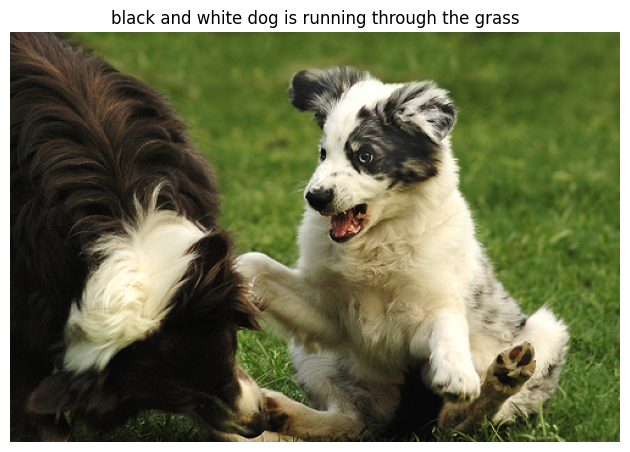

In [14]:
import random

def generate_caption(model, tokenizer, photo_feature, max_len):
    """Greedy-search caption generation."""
    in_text = 'startseq'
    for _ in range(max_len):
        seq  = pad_sequences([tokenizer.texts_to_sequences([in_text])[0]], maxlen=max_len)
        yhat = model.predict([photo_feature.reshape(1, 2048), seq], verbose=0)
        word = tokenizer.index_word.get(np.argmax(yhat))
        if word is None or word == 'endseq':
            break
        in_text += ' ' + word
    return ' '.join(in_text.split()[1:])  # strip 'startseq'


# Pick a random test image
img_name = random.choice(os.listdir(IMAGES_DIR))
img_path = os.path.join(IMAGES_DIR, img_name)
print("Testing image:", img_name)

# Extract feature with Xception model (not caption_model!)
photo = extract_single_feature(img_path)

# Generate caption using the captioning model
caption = generate_caption(caption_model, tokenizer, photo, max_len)
print("Generated Caption:", caption)

# Display
plt.imshow(Image.open(img_path))
plt.axis('off')
plt.title(caption, fontsize=12)
plt.tight_layout()
plt.show()